In [ ]:
pip install -qqq ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
plate_ocr = YOLO('/content/ocr.pt')
plate_detection = YOLO('/content/plate.pt')


0: 640x480 3 license-plates, 363.2ms
Speed: 23.4ms preprocess, 363.2ms inference, 32.2ms postprocess per image at shape (1, 3, 640, 480)


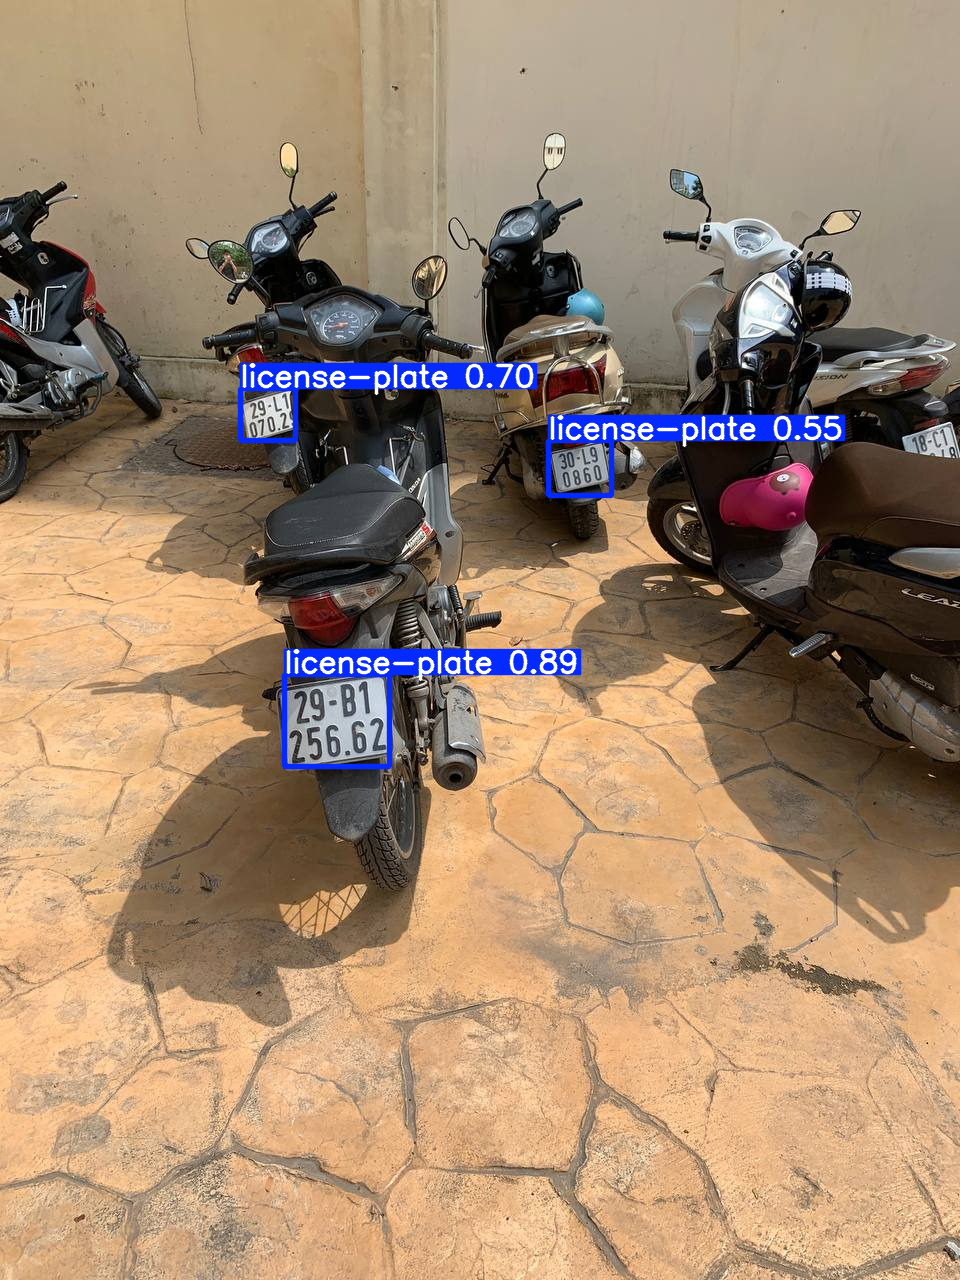

In [ ]:
img = cv2.imread('/content/101.jpg')

results = plate_detection(img, conf = 0.5)
results[0].show()

In [ ]:
from sklearn.cluster import KMeans

def getLPText(plate_crop, plate_ocr):
    """
    Extracts text from a license plate using OCR after correcting skew.

    Args:
    - plate_crop (numpy array): Cropped license plate image.
    - plate_ocr (object): OCR model
    Returns:
    - final_text (str): Detected license plate text.
    """
    # Run OCR
    text_plate = plate_ocr(plate_crop)

    ocr_pre = text_plate[0]
    id2char = plate_ocr.names
    boxes = ocr_pre.boxes

    cls_ids = boxes.cls.cpu().numpy().astype(int)
    box_coords = boxes.xyxy.cpu().numpy()
    combined = list(zip(box_coords, cls_ids))

    # Cluster based on vertical (Y) position
    y_centers = np.array([[((box[1] + box[3]) / 2)] for box, _ in combined])
    n_clusters = 2 if len(combined) >= 6 else 1

    kmeans = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(y_centers)

    # Group by row clusters
    rows = [[] for _ in range(n_clusters)]
    for (box, cls_id), label in zip(combined, labels):
        x1 = box[0]
        rows[label].append((x1, cls_id))

    # Sort rows top-to-bottom
    row_avg_y = [np.mean([y_centers[i][0] for i in range(len(labels)) if labels[i] == r]) for r in range(n_clusters)]
    sorted_rows = [row for _, row in sorted(zip(row_avg_y, rows), key=lambda x: x[0])]

    # Sort each row left-to-right
    detected_text = []
    for row in sorted_rows:
        row.sort(key=lambda item: item[0])  # sort by x
        row_text = ''.join(id2char[cls_id] for _, cls_id in row)
        detected_text.append(row_text)

    final_text = ''.join(detected_text)
    return final_text

In [ ]:
import numpy as np
for box in results[0].boxes:
    class_id = int(box.cls[0])
    if class_id == 0:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        plate_crop = img[y1:y2, x1:x2]
        final_lp = getLPText(plate_crop, plate_ocr)
        print("Detected text:", final_lp)


0: 576x640 1 1, 3 2s, 1 5, 2 6s, 1 9, 1 B, 271.2ms
Speed: 6.6ms preprocess, 271.2ms inference, 1.2ms postprocess per image at shape (1, 3, 576, 640)
Detected text: 29B125662

0: 608x640 1 1, 2 2s, 1 7, 2 9s, 1 L, 2 0s, 272.4ms
Speed: 4.1ms preprocess, 272.4ms inference, 1.3ms postprocess per image at shape (1, 3, 608, 640)
Detected text: 29L107029

0: 576x640 1 3, 1 6, 1 8, 1 9, 1 L, 3 0s, 211.5ms
Speed: 3.7ms preprocess, 211.5ms inference, 1.2ms postprocess per image at shape (1, 3, 576, 640)
Detected text: 30L90860
